# Model Misspecification

**Model specification** refers to the selection of the general function that we are fitting to the data. We need to select:

- the **dependent variable(s)** that we are trying to explain
- the **independent variable(s)** (explanatory variables, predictors)
- the **functional form**

For instance, we may assume that the dependent variable is a linear function of two independent variables. If the model is not correctly specified, regression assumptions will be violated and the model will not be accurate.

Below we define and explain many of the common **model specification errors**.

In [65]:
import numpy as np
import statsmodels.api as sm
import yfinance as yf
import pandas as pd
import warnings
import requests
from matplotlib import pyplot as plt
from statsmodels import regression
from statsmodels.tsa.stattools import adfuller
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

### 1) Exclusion of Important Variables

If we omit a variable which is **uncorrelated** with the variables that we do include, we will simply not explain the dependent variable as well as we could.

However, if the omitted variable (say, $X_2$) is **correlated** with the included variable ($X_1$), then the omission additionally affects the model. The **coefficient of $X_1$** and the **constant term** in the regression will be **biased** — they try to compensate for the omission of $X_2$.

This means:

- The estimated coefficients will be **inconsistent**
- The estimated effect of $X_1$ on the dependent variable will be incorrect
- Estimated standard errors of the coefficients will also be inconsistent

In particular, we may be led to believe that two variables have a **causal relationship** because of their high correlation, when in fact they are both correlated with a third variable (omitted variable bias).

**Example**: If two stocks both follow the market, or if two quantities both tend to increase with time, they will appear highly correlated — even if neither directly causes the other.

In [3]:
start_date = '2013-01-01'
end_date = '2015-01-01'

benchmark_ticker = 'SPY'
asset1_ticker = 'AAPL'
asset2_ticker = 'LRCX'

asset1_price = yf.download(asset1_ticker, start=start_date, end=end_date)['Close']
asset2_price = yf.download(asset2_ticker, start=start_date, end=end_date)['Close']
benchmark_price = yf.download(benchmark_ticker, start=start_date, end=end_date)['Close']

# Perform a linear regression and get the r-sqaured value
slr12 = regression.linear_model.OLS(asset1_price, sm.add_constant(asset2_price)).fit()
slrb1 = regression.linear_model.OLS(asset1_price, sm.add_constant(benchmark_price)).fit()
slrb2 = regression.linear_model.OLS(asset2_price, sm.add_constant(benchmark_price)).fit()

print(f'R-squared of asset 1 (AAPL) regressed on asset 2 (LRCX): {slr12.rsquared:.4f}')
print(f'R-squared of asset 1 (AAPL) regressed on benchmark (SPY): {slrb1.rsquared:.4f}')
print(f'R-squared of asset 2 (LRCX) regressed on benchmark (SPY): {slrb2.rsquared:.4f}')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

R-squared of asset 1 (AAPL) regressed on asset 2 (LRCX): 0.9206
R-squared of asset 1 (AAPL) regressed on benchmark (SPY): 0.8242
R-squared of asset 2 (LRCX) regressed on benchmark (SPY): 0.8818


It is dangerous to simply assume that AAPL (Apple) and LRCX (Lam Research) are directly or meaningfully correlated — in the sense of one driving the other or them having a special pairwise relationship — just because their returns show a high R-squared (here, 0.9206 when regressing AAPL on LRCX). This high value looks impressive at first glance, but it often reflects spurious correlation driven by a common underlying factor rather than any direct economic link between the two companies.

Both stocks are strongly explained by the overall market (SPY). When two assets have high R² with the same third variable (the market), they will naturally show a high R² with each other — even if neither one directly causes or influences the other.This is a classic case of omitted variable bias (or confounding). The omitted variable here is broad market/systematic risk (often proxied by SPY). Both AAPL (a large-cap tech/consumer giant) and LRCX (a semiconductor equipment leader) are heavily exposed to:
- Overall equity market movements
- Tech sector trends
- Macro factors like interest rates, economic growth, risk appetite, and (especially in recent years) AI/semiconductor demand cycles

The apparent strong "correlation" between AAPL and LRCX is largely them both riding the same market wave, not a unique pairwise relationship.

It is hard to see consistency, or lack of it, since it is **asymptotic** and **probabilistic**. However, we can extend our sample period to see how the $R^2$ value changes. The **correlation** between the stocks and the market seems to persist, while the **correlation between the two stocks** drops. 

So we would be **better off** predicting the stock prices from the **market price** than from each other.

Now, we can extend the time period and see how their R-Square varies

In [4]:
start_date = '2009-01-01'
end_date = '2015-01-01'

benchmark_ticker = 'SPY'
asset1_ticker = 'AAPL'
asset2_ticker = 'LRCX'

asset1_price = yf.download(asset1_ticker, start=start_date, end=end_date)['Close']
asset2_price = yf.download(asset2_ticker, start=start_date, end=end_date)['Close']
benchmark_price = yf.download(benchmark_ticker, start=start_date, end=end_date)['Close']

# Perform a linear regression and get the r-sqaured value
slr12 = regression.linear_model.OLS(asset1_price, sm.add_constant(asset2_price)).fit()
slrb1 = regression.linear_model.OLS(asset1_price, sm.add_constant(benchmark_price)).fit()
slrb2 = regression.linear_model.OLS(asset2_price, sm.add_constant(benchmark_price)).fit()

print(f'R-squared of asset 1 (AAPL) regressed on asset 2 (LRCX): {slr12.rsquared:.4f}')
print(f'R-squared of asset 1 (AAPL) regressed on benchmark (SPY): {slrb1.rsquared:.4f}')
print(f'R-squared of asset 2 (LRCX) regressed on benchmark (SPY): {slrb2.rsquared:.4f}')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

R-squared of asset 1 (AAPL) regressed on asset 2 (LRCX): 0.5309
R-squared of asset 1 (AAPL) regressed on benchmark (SPY): 0.7888
R-squared of asset 2 (LRCX) regressed on benchmark (SPY): 0.7366


As we can see above, the R-square between AAPL and LRCX is reduced to 0.5309, compared to the previous high of 0.9206.

### 2) Inclusion of Unnecessary Variables

Conversely, we can have a model which includes **too many independent variables**. If we include a truly **unnecessary variable**, we will have:
- a **lower adjusted R-squared**
- **less precise** estimates (larger standard errors) of the other regression coefficients

That is, our analysis of the model will be **weakened**, but the model itself will not change in terms of bias (the coefficients remain unbiased if the variable is truly irrelevant).

However, if we include variables that are only **slightly correlated** and mostly irrelevant, they can artificially **improve the fit** and the **R-squared** of our model by adding small bits of variation that conform to the sample data. This runs the risk of **overfitting**, since the small adjustments we make are **sample-specific** (they do not generalize well to new data).

**Example**  

Below we run a regression with **PEP** price as the independent variable and **PG** price as the dependent variable (which makes some sense as they are in the same sector — both consumer staples, competitors in beverages/snacks and household/personal care). We then run another regression with **three random other stocks** added as additional independent variables.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Adjusted R-squared of simple linear regression: 0.7897
Adjusted R-squared of multiple linear regression: 0.8832


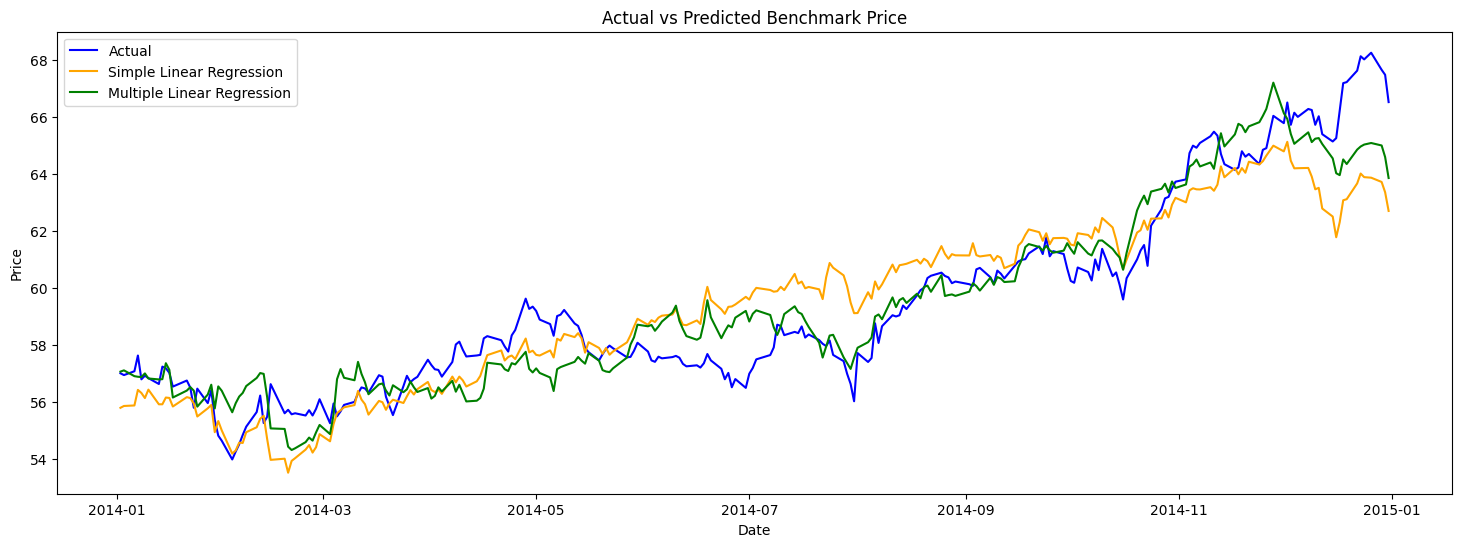

In [11]:
start_date = '2014-01-01'
end_date = '2015-01-01'

x1_ticker = 'PEP'
x2_ticker = 'IBM'
x3_ticker = 'XOM'
x4_ticker = 'GE'
y1_ticker = 'PG'

x1_price = yf.download(x1_ticker, start=start_date, end=end_date)['Close']
x2_price = yf.download(x2_ticker, start=start_date, end=end_date)['Close']
x3_price = yf.download(x3_ticker, start=start_date, end=end_date)['Close']
x4_price = yf.download(x4_ticker, start=start_date, end=end_date)['Close']
y1_price = yf.download(y1_ticker, start=start_date, end=end_date)['Close']

# Build a linear regression model to on;y explain y with x1
slr = regression.linear_model.OLS(y1_price, sm.add_constant(x1_price)).fit()
slr_prediction = slr.params[0] + slr.params[1] * x1_price[x1_ticker]

# Run multiple linear regression to explain y with x1, x2, x3 and x4
mlr = regression.linear_model.OLS(y1_price, sm.add_constant(pd.concat([x1_price, x2_price, x3_price, x4_price], axis=1))).fit()
mlr_prediction = mlr.params[0] + mlr.params[1] * x1_price[x1_ticker] + mlr.params[2] * x2_price[x2_ticker] + mlr.params[3] * x3_price[x3_ticker] + mlr.params[4] * x4_price[x4_ticker]

# Compute the adjusted r-squared for both models
print(f'Adjusted R-squared of simple linear regression: {slr.rsquared_adj:.4f}')
print(f'Adjusted R-squared of multiple linear regression: {mlr.rsquared_adj:.4f}')

# Plot y along with the two different predictions
plt.figure(figsize=(18, 6))
plt.plot(y1_price.index, y1_price, label='Actual', color='blue')
plt.plot(slr_prediction.index, slr_prediction, label='Simple Linear Regression', color='orange')
plt.plot(mlr_prediction.index, mlr_prediction, label='Multiple Linear Regression', color='green')
plt.title('Actual vs Predicted Benchmark Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

We are able to tune the model **more precisely** to the data by including more variables. Note that although **adjusted R-squared** penalizes us for using more variables, the number of samples here is **so large** that the adjustment/penalty is **tiny**. Let us see what happens if we use the **same linear models** to **predict the price of PG** for the **next six months**

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Adjusted R-squared of simple linear regression: -0.81133593
Adjusted R-squared of multiple linear regression: -5.42733444


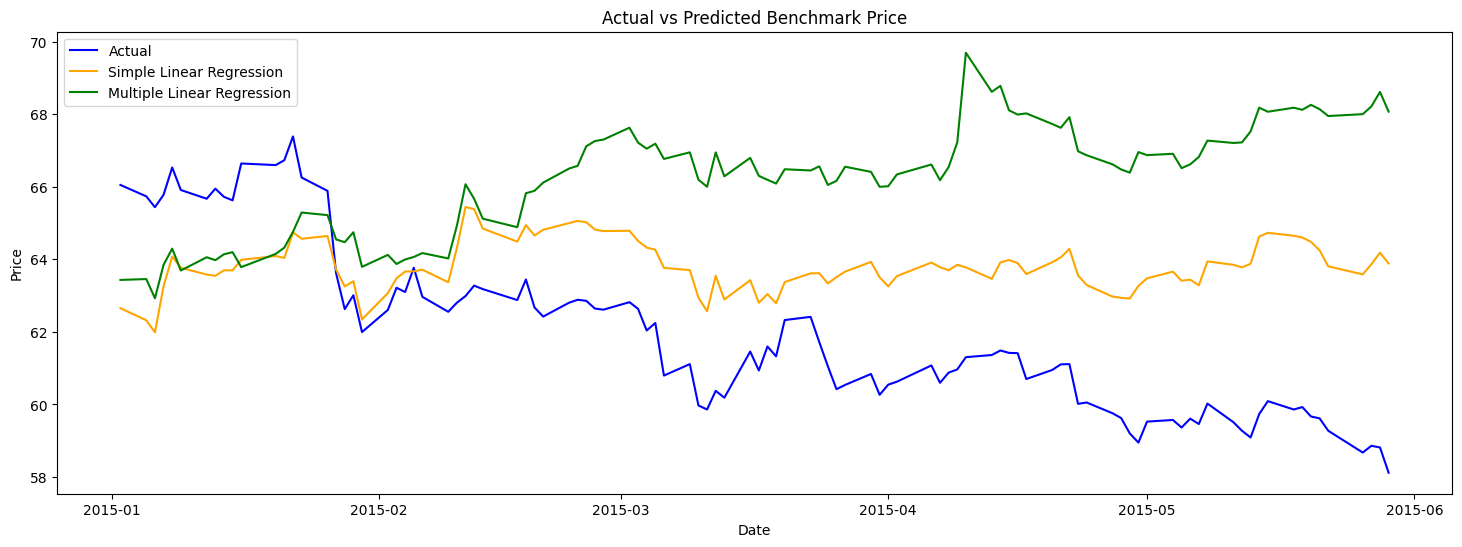

In [13]:
start_date = '2015-01-01'
end_date = '2015-06-01'

x1_ticker = 'PEP'
x2_ticker = 'IBM'
x3_ticker = 'XOM'
x4_ticker = 'GE'
y1_ticker = 'PG'

x1_price = yf.download(x1_ticker, start=start_date, end=end_date)['Close']
x2_price = yf.download(x2_ticker, start=start_date, end=end_date)['Close']
x3_price = yf.download(x3_ticker, start=start_date, end=end_date)['Close']
x4_price = yf.download(x4_ticker, start=start_date, end=end_date)['Close']
y1_price = yf.download(y1_ticker, start=start_date, end=end_date)['Close']

slr_predictions2 = slr.params[0] + slr.params[1] * x1_price[x1_ticker]
mlr_predictions2 = mlr.params[0] + mlr.params[1] * x1_price[x1_ticker] + mlr.params[2] * x2_price[x2_ticker] + mlr.params[3] * x3_price[x3_ticker] + mlr.params[4] * x4_price[x4_ticker]

# Compute the adjusted r-squared for both models over the new time period
adj = float(len(y1_price) - 1) / (len(y1_price) - 5)
SST = sum((y1_price[y1_ticker] - np.mean(y1_price[y1_ticker])) ** 2)
SSRs = sum((y1_price[y1_ticker] - slr_predictions2) ** 2)
SSRm = sum((y1_price[y1_ticker] - mlr_predictions2) ** 2)

print(f'Adjusted R-squared of simple linear regression: {1 - (SSRs / SST) * adj:.8f}')
print(f'Adjusted R-squared of multiple linear regression: {1 - (SSRm / SST) * adj:.8f}')

# Plot y along with the two different predictions
plt.figure(figsize=(18, 6))
plt.plot(y1_price.index, y1_price, label='Actual', color='blue')
plt.plot(slr_predictions2.index, slr_predictions2, label='Simple Linear Regression', color='orange')
plt.plot(mlr_predictions2.index, mlr_predictions2, label='Multiple Linear Regression', color='green')
plt.title('Actual vs Predicted Benchmark Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

Remarks:

---

The example highlights a key danger in regression modeling: including too many unnecessary variables leads to overfitting, where the model appears excellent on historical (in-sample) data but fails badly when predicting new (out-of-sample) data. In the training period, the simple linear regression using only PEP price as a predictor for PG price achieved an adjusted R-squared of 0.7897, while adding three random, irrelevant stocks boosted the multiple regression's adjusted R-squared to 0.8832—even after the penalty—because the large sample size made the adjustment for extra variables negligible, allowing the model to fit random noise more closely. However, when both models were used to forecast PG prices over the next six months, the results diverged dramatically: the simple model produced an out-of-sample adjusted R-squared of -0.81 (worse than simply predicting the historical mean), while the overfitted multiple model collapsed to an abysmal -5.43. 

Visually, during the training period both predictions tracked actual prices reasonably well (with the multiple model hugging fluctuations slightly better), but in the hold-out period the actual PG price trended steadily downward while the simple model remained relatively flat and the multiple model swung wildly upward and oscillated, producing large, unreliable overpredictions. This stark contrast demonstrates that unnecessary variables capture sample-specific quirks rather than true underlying relationships, inflating in-sample fit at the expense of generalization, stability, and predictive accuracy—making simpler, economically meaningful models far more reliable for real-world forecasting.

### 3) Errors in Independent Variables (Measurement Error)

If we use indices or dates as our independent variables, they are error-free. However, when we wish to use the value of a stock $X_t$ as an independent variable, we can only measure the price, which is full of small, random fluctuations. So we actually observe $Z_t = X_t + u_t$ for some error $u_t$. Our intended (true) model is:

$$
Y_t = b_0 + b_1 X_t + \epsilon_t
$$

that is, that some variable is linearly related to the **true** value of the stock. But since we only know the noisy value $Z_t$, we actually estimate:

$$
Y_t = b_0 + b_1 Z_t + (-b_1 u_t + \epsilon_t)
$$

If $u_t$ is **not correlated** with $X_t$, then it **will be correlated** with $Z_t$, and so the composite error term $-b_1 u_t + \epsilon_t$ will be correlated with our observed independent variable $Z_t$. Consequently, the coefficients will be **biased and inconsistent**. In particular, $b_1$ will be **biased downward** (attenuation bias / classical measurement error bias).

#### Incorrect Functional Form

After we pick the variables we wish to include, we need to specify the shape of the function. A regression requires the relationship to be linear in the coefficients, but we can manipulate the variables to achieve various types of functions. For instance:
- The model $Y_i = b_0 + b_1 X_i + b_2 X_i^2 + \epsilon_i$ gives a **quadratic** relationship  
- The log-linear model $\ln Y_i = b_0 + b_1 X_i + \epsilon_i$ gives an **exponential** relationship  
  (we expect the rate of growth of $Y$ to be related to $X$)

Generally, we select the functional form based on our expectation of the relationship. For example, a log-linear model is good when we expect proportional or percentage changes.

If a **wrong** functional form is selected, then we may be unable to get a good fit. In fact, the model may lead to **absurd conclusions**. For example, if we use a linear model where a logarithmic one would have been more appropriate, we may predict that the number of companies in a certain category becomes **negative** instead of approaching zero.

We also have to be careful not to pick a functional form that **overfits** the data. Arbitrarily using high-degree polynomials leads to overfitting since they have many degrees of freedom. This is a future issue in data-mining: if we try different models until we find the one that looks best in-sample, we are overfitting at the expense of future predictivity.

#### Pooling Different Populations

If we attempt to use one model for two populations for which separate models would be more appropriate, we may get results that are misleading or that fit well only artificially.

For instance, if we mix data about men's and women's wages (where separate models would be more appropriate), the combined model may be too spread out or give misleading coefficients that do not accurately represent either group, as in the artificial example below.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.471
Method:                 Least Squares   F-statistic:                     53.45
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           8.80e-10
Time:                        22:30:56   Log-Likelihood:                -272.82
No. Observations:                  60   AIC:                             549.6
Df Residuals:                      58   BIC:                             553.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1538      5.849      0.539      0.5

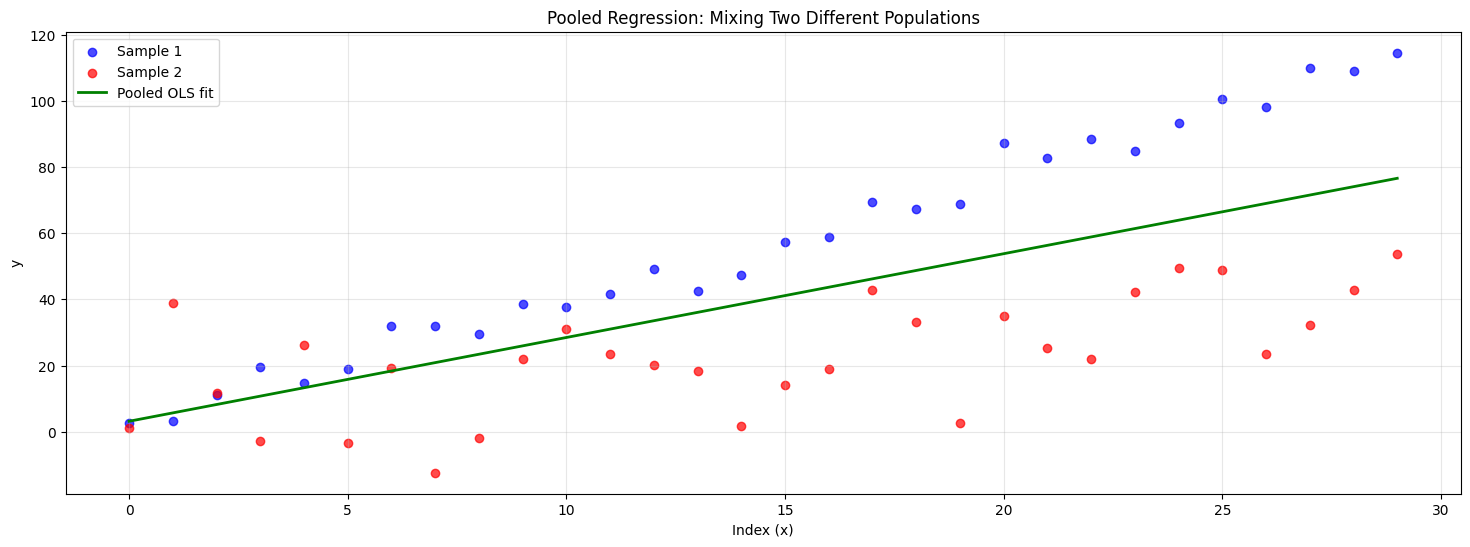

In [ ]:
# Generate two artificial samples with different patterns
# Sample 1: y = 4 * x + noise
np.random.seed(42)  # for reproducibility
x = np.arange(30)
sample1 = 4 * x + np.random.normal(0, 5, 30)   # moderate positive slope

# Sample 2: y = x + larger noise + offset (different relationship)
sample2 = x + np.random.normal(10, 15, 30)     # flatter slope, higher level

# Pool the two samples
pool = np.hstack((sample1, sample2))

# Create the independent variable: original indices repeated for each sample
# (0 to 29 for first sample, 0 to 29 again for second sample)
x_pool = np.hstack((np.arange(30), np.arange(30)))

# Add constant for intercept → X matrix
X = sm.add_constant(x_pool)

# Run OLS regression on pooled data
model = sm.OLS(pool, X).fit()

# Print summary to see coefficients
print(model.summary())

# Plot
plt.figure(figsize=(18, 6))

# Scatter: first sample (blue), second sample (red)
plt.scatter(np.arange(30), sample1, color='b', label='Sample 1', alpha=0.7)
plt.scatter(np.arange(30), sample2, color='r', label='Sample 2', alpha=0.7)

# Plot the pooled regression line
x_line = np.arange(30)
y_line = model.params[0] + model.params[1] * x_line
plt.plot(x_line, y_line, color='g', linewidth=2, label='Pooled OLS fit')
plt.xlabel('Index (x)')
plt.ylabel('y')
plt.title('Pooled Regression: Mixing Two Different Populations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

It is clear that **two separate models** for the two datasets would be more appropriate. Note that, as above, pooling can lead to assumption violations such as **heteroskedasticity** and errors that are **not normally distributed**.

Conversely, we can pool datasets of observations that separately demonstrate no correlation, but do appear to fit a correlation model when taken together. To see why this might be a problem, consider a model that compares companies' **free cash flow** with **cash flow from operations**. However, below we scale both datasets so that there is a correlation between the two for transportation companies with **market cap > $100 million**. That is, the correlation between **free cash flow**, **revenue**, and **cash flow from operations** is largely due to **company size**, and thus does not give us any real information about the relationship between free cash flow and cash flow from operations after controlling for size.

The apparent fit in the pooled data is therefore **spurious** — driven by the confounding effect of company size rather than a true underlying relationship.

In [33]:
# Define a function to get the fundamental data for a list of tickers
def get_fundamentals():
  url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
  headers = {
    "User-Agent": "Mozilla/5.0"
  }
  response = requests.get(url, headers=headers)
  tables = pd.read_html(response.text)
  tickers = tables[0]['Symbol'].tolist()

  # Download fundamentals in bulk
  data = {}

  for t in tickers:
    try:
      info = yf.Ticker(t).info
      data[t] = {
        "market_cap": info.get("marketCap"),
        "book_value": info.get("bookValue"),
        "price_to_book": info.get("priceToBook"),
        "book_to_price": 1 / info.get("priceToBook") if info.get("priceToBook") else None,
        "book_value_yield": info.get("bookValue") / info.get("currentPrice") if info.get("currentPrice") else None,
        "operating_cash_flow": info.get("operatingCashflow"),
        "free_cash_flow": info.get("freeCashflow"),
        "total_revenue": info.get("totalRevenue"),
      }
      data_df = pd.DataFrame.from_dict(data, orient="index")
      # Save it to a CSV file after each ticker to avoid losing data if the script is interrupted
      data_df.to_csv("sp500_fundamentals_detailed.csv")
    except Exception as e:
      pass
  return data_df

# Define a function that gets the price data of the input assets from Yahoo Finance
def get_prices(tickers, start_date, end_date):
  prices = yf.download(tickers, start=start_date, end=end_date)
  # Drop stocks that have NaN values in the 'Close' column (e.g., due to delisting or missing data)
  prices = prices["Close"].dropna(axis=1, how='any')
  return prices

# Check if we already have the fundamentals data saved locally to avoid unnecessary API calls
try:
  data = pd.read_csv("sp500_fundamentals_detailed.csv", index_col=0)
except Exception as e:
  data = get_fundamentals()

Run a linear regression and print the R-squared vlaue to evaluate the goodness of fit

                             OLS Regression Results                            
Dep. Variable:     operating_cash_flow   R-squared:                       0.560
Model:                             OLS   Adj. R-squared:                  0.560
Method:                  Least Squares   F-statistic:                     598.1
Date:                 Thu, 05 Mar 2026   Prob (F-statistic):           9.33e-86
Time:                         22:46:38   Log-Likelihood:                -11591.
No. Observations:                  471   AIC:                         2.319e+04
Df Residuals:                      469   BIC:                         2.319e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           1.897e+09   5.79e+

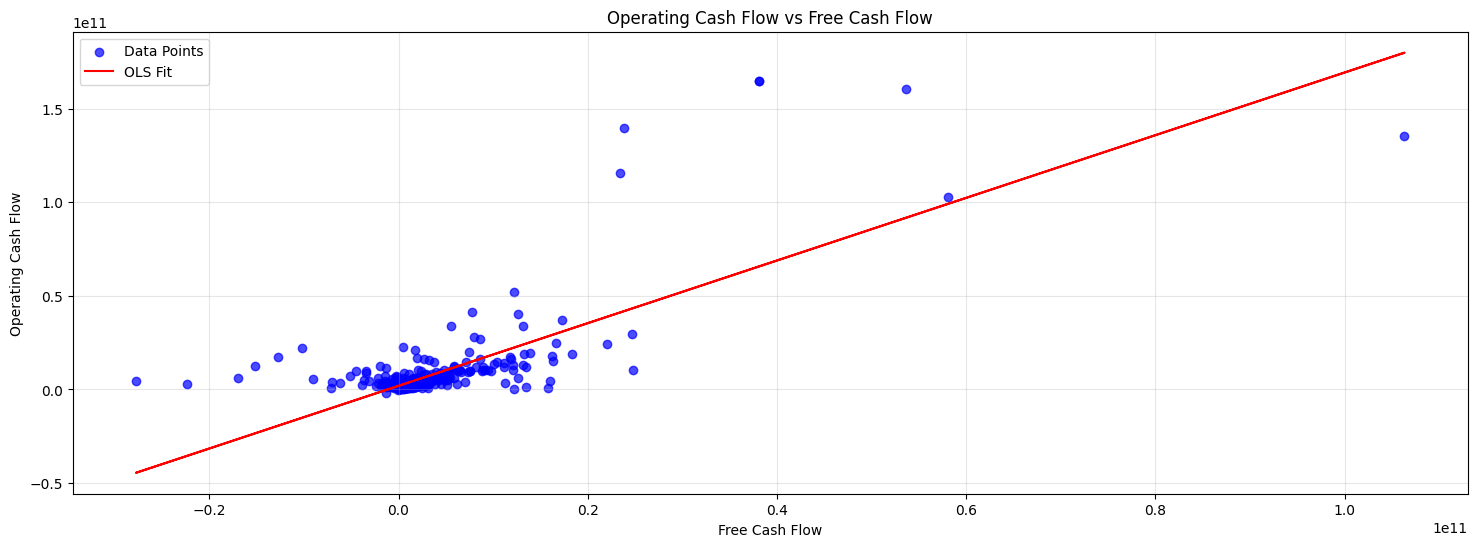

In [44]:
data = data.dropna()
unscaled_model = regression.linear_model.OLS(data['operating_cash_flow'], sm.add_constant(data['free_cash_flow'])).fit()
prediction = unscaled_model.params[0] + unscaled_model.params[1] * data['free_cash_flow']
print(unscaled_model.summary())

print("R-squared of unscaled model:", unscaled_model.rsquared)

# Plot the raw data for visualization
plt.figure(figsize=(18, 6))
plt.scatter(data['free_cash_flow'], data['operating_cash_flow'], color='blue', alpha=0.7, label='Data Points')
plt.plot(data['free_cash_flow'], prediction, color='red', label='OLS Fit')
plt.xlabel('Free Cash Flow')
plt.ylabel('Operating Cash Flow')
plt.title('Operating Cash Flow vs Free Cash Flow')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Now, let us scale by total revenue and see the new results

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     50.37
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           4.73e-12
Time:                        22:47:59   Log-Likelihood:                 235.39
No. Observations:                 471   AIC:                            -466.8
Df Residuals:                     469   BIC:                            -458.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2094      0.008     27.228      0.0

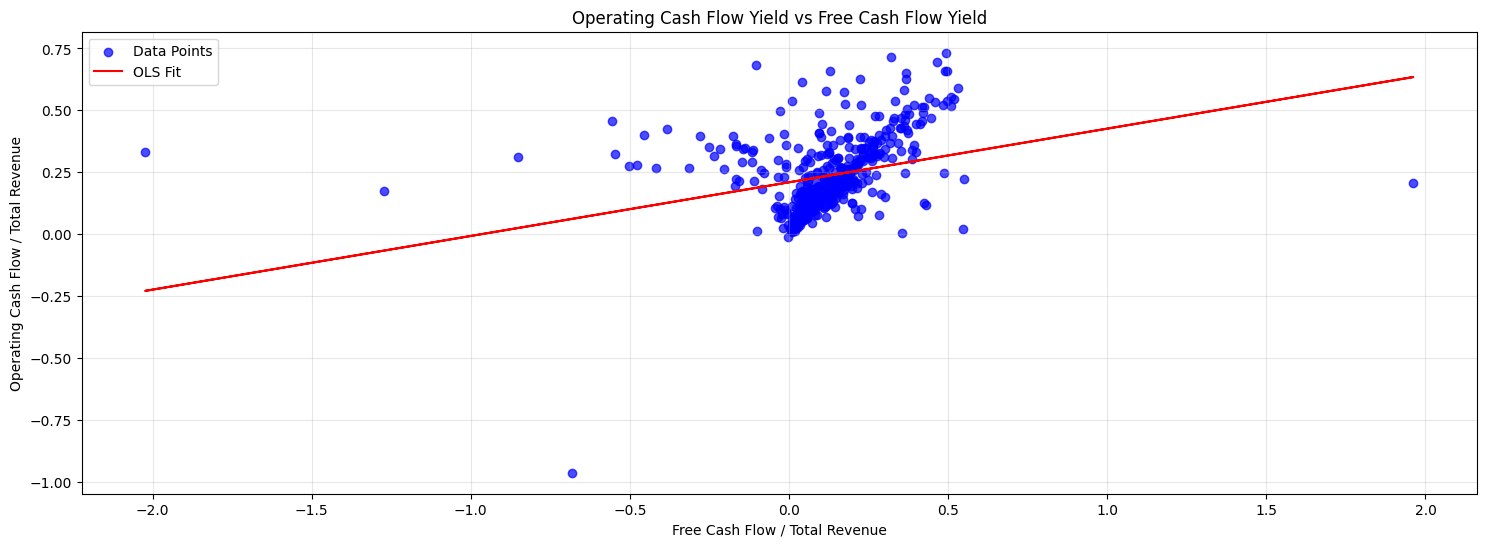

In [52]:
data = data.dropna()
scaled_model = regression.linear_model.OLS(data['operating_cash_flow']/data['total_revenue'], sm.add_constant(data['free_cash_flow']/data['total_revenue'])).fit()

print(scaled_model.summary())
print("R-squared of scaled model:", scaled_model.rsquared)

prediction = scaled_model.params['const'] + scaled_model.params[0] * (data['free_cash_flow']/data['total_revenue'])

# Plot the scaled data for visualization
plt.figure(figsize=(18, 6))
plt.scatter(data['free_cash_flow']/data['total_revenue'], data['operating_cash_flow']/data['total_revenue'], color='blue', alpha=0.7, label='Data Points')
plt.plot(data['free_cash_flow']/data['total_revenue'], prediction, color='red', label='OLS Fit')
plt.xlabel('Free Cash Flow / Total Revenue')
plt.ylabel('Operating Cash Flow / Total Revenue')
plt.title('Operating Cash Flow Yield vs Free Cash Flow Yield')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We can see that after scaling, the R-squared dropped

### 4) Nonstationary Time Series

A **stationary** process is one whose joint probability distribution does not change with time. In particular, its **mean** and **variance** are constant through time.

When we apply regression models to time series data, we must make the additional assumption that the series are **stationary**. Otherwise, the usual statistical properties (t-statistics, confidence intervals, hypothesis tests) for the parameters will **not be valid**.

A **random walk** is a process for which the best estimate for the next value is the previous value. If you were to walk randomly, your location after each step would be somewhere near your previous location but in an unpredictable direction. Formally, such a one-dimensional random walk is described by the equation:

$$
x_t = x_{t-1} + \epsilon_t
$$

where the error $\epsilon_t$ is homoskedastic, has mean zero, and is not autocorrelated. Random walks have **variance increasing** with time and are therefore **nonstationary**.

For example, exchange rates are often assumed to be (close to) random walks. Two independent random walks will **very often appear highly correlated** when plotted together. They are subject to **spurious regression** results. 

**Try running the code below several times** to see how two unrelated random walks can produce a misleadingly high R-squared and significant coefficients.

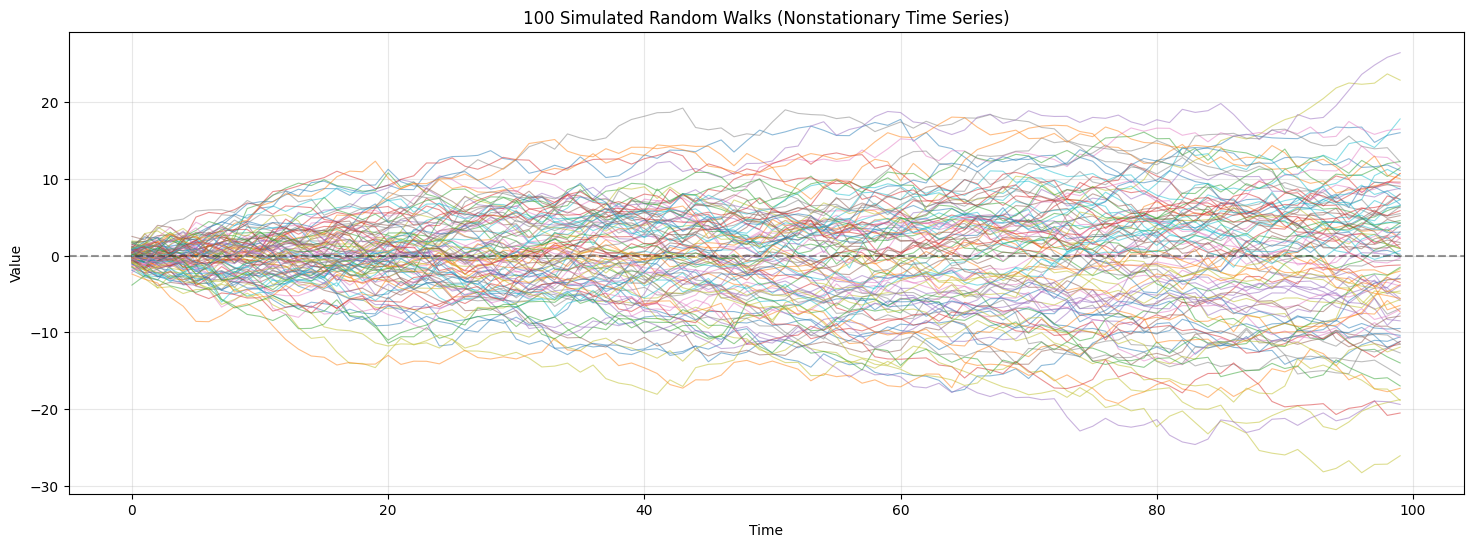

In [53]:
# Set random seed for reproducibility (optional but recommended)
np.random.seed(42)

# Number of time steps
n = 100

# Generate normally distributed errors for multiple random walks
# (e.g., 100 separate random walks, each with 100 steps)
n_walks = 100
errors = np.random.randn(n_walks, n)          # shape: (100 walks, 100 steps)

# Compute the random walks: cumulative sum of errors along time axis
random_walks = np.cumsum(errors, axis=1)      # shape: (100, 100)

# Optional: also compute cumulative sum across walks if needed (not used in plot below)
# y = np.sum(random_walks, axis=0)           # sum of all walks at each time
# yw = np.cumsum(y)                           # cumulative of that sum (rarely used)

# Plot all random walks
plt.figure(figsize=(18, 6))

for i in range(n_walks):
  plt.plot(random_walks[i], alpha=0.5, linewidth=0.8)

plt.title('100 Simulated Random Walks (Nonstationary Time Series)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linestyle='--', alpha=0.4)
plt.show()

Number of random walks with R-squared > 0.8: 14 out of 100


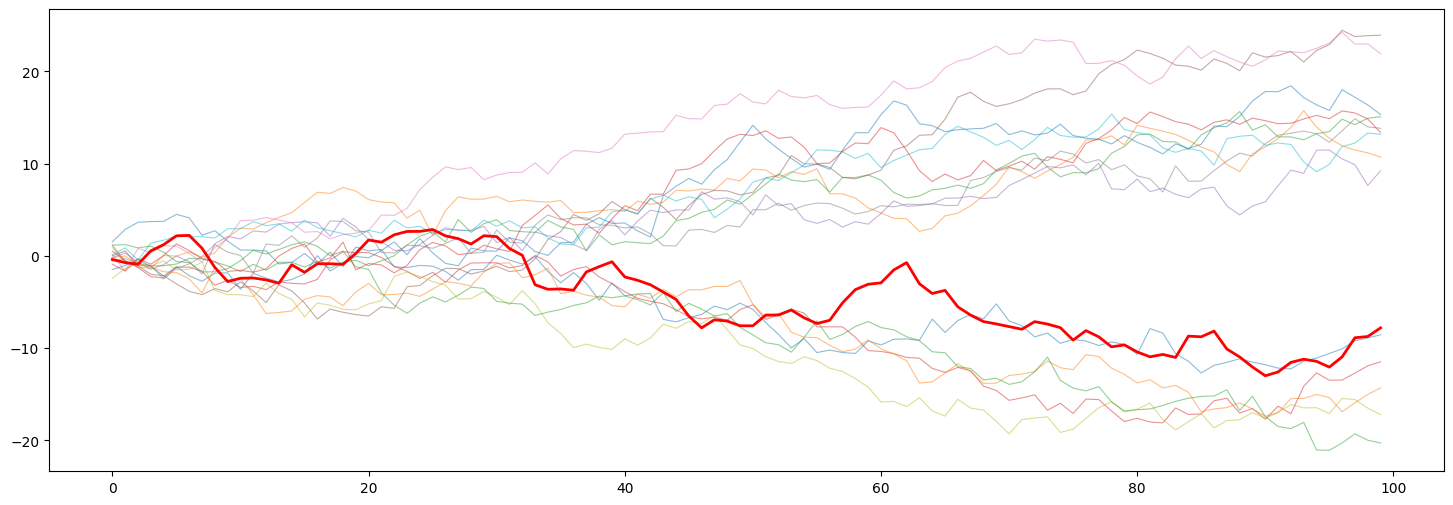

In [62]:
y = np.random.randn(n)              # independent variable (time)
yw = [sum(y[:i+1]) for i in range(n)]
rs = [regression.linear_model.OLS(yw, x).fit().rsquared for x in random_walks]

# Plot and count the random walks that have r-squared with yx > 0.8
plt.figure(figsize=(18, 6))
rcount = 0
for i in range(n_walks):
  if rs[i] > 0.8:
    rcount += 1
    plt.plot(random_walks[i], alpha=0.5, linewidth=0.8)

print(f'Number of random walks with R-squared > 0.8: {rcount} out of {n_walks}')
plt.plot(yw, color='red', linewidth=2, label='Cumulative Sum (yw)')

The reason for the two branches above is that a **linear fit works well** for both **positively** and **negatively** correlated variables.

The result is even more extreme if we look at the random walks that show **significant correlation**, according to the **p-values**  of their correlation coefficients:

Number of random walks with p-value < 0.05: 87 out of 100


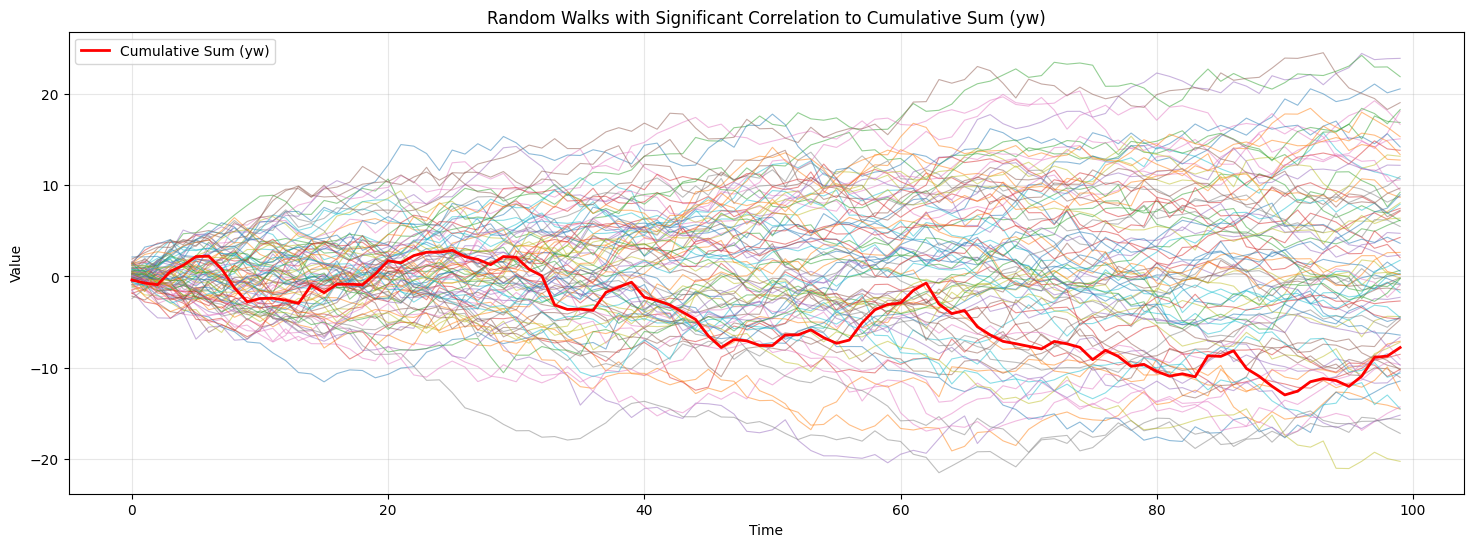

In [64]:
ps = [pearsonr(yw, x)[1] for x in random_walks]

# Plot and count the number of random walks that have p-value with yx < 0.05
plt.figure(figsize=(18, 6))
rcount = 0
for i in range(n_walks):
  if ps[i] < 0.05:
    rcount += 1
    plt.plot(random_walks[i], alpha=0.5, linewidth=0.8)
    
print(f'Number of random walks with p-value < 0.05: {rcount} out of {n_walks}')
plt.plot(yw, color='red', linewidth=2, label='Cumulative Sum (yw)')
plt.title('Random Walks with Significant Correlation to Cumulative Sum (yw)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Due to the high probability of **spurious results**, the fit statistics (t-statistics, F-tests, R² significance, etc.) that we compute when regressing **random walks** (or other nonstationary series) are **invalid** Furthermore, the **parameter estimates are inconsistent**. We can detect random walks and related time series (such as a random walk with drift) by checking for the presence of a **unit root** in the time series — that is, whether or not it appears to follow the equation:

$$
x_t = x_{t-1} + \epsilon_t
$$

One common method is the **Dickey-Fuller test**.

In [66]:
result = adfuller(yw)
print(result[1])          # p-value

0.5302344733042814


Therefore, we cannot reject the hypothesis that yw has a unit root (as we know it does, by construction — it is the cumulative sum of sums of random errors).